In [3]:
!pip install kagglehub pandas

In [4]:
import kagglehub
import pandas as pd
import os

# Descargar el dataset
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Carpeta del dataset:", path)

# Listar todos los archivos descargados
files = os.listdir(path)
print("\nArchivos encontrados:")
for f in files:
    print(f"- {f}")

Carpeta del dataset: /Users/sergio/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2

Archivos encontrados:
- olist_sellers_dataset.csv
- product_category_name_translation.csv
- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv


In [5]:
import pandas as pd
import os

# 1. Cargar todos los archivos
# Asumimos que 'path' es la variable que obtuviste con kagglehub
dfs = {}
files = [
    'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv',
    'olist_products_dataset.csv', 'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]

for f in files:
    name = f.replace('.csv', '')
    dfs[name] = pd.read_csv(os.path.join(path, f))

# 2. Empezamos la integración siguiendo el diagrama
# Nota: Usamos 'left' join para no perder órdenes que quizás no tengan reviews o pagos todavía

# A. Órdenes + Clientes (Vínculo: customer_id)
m = pd.merge(dfs['olist_orders_dataset'], dfs['olist_customers_dataset'], on='customer_id', how='left')

# B. + Pagos (Vínculo: order_id)
m = pd.merge(m, dfs['olist_order_payments_dataset'], on='order_id', how='left')

# C. + Reseñas (Vínculo: order_id)
m = pd.merge(m, dfs['olist_order_reviews_dataset'], on='order_id', how='left')

# D. + Ítems (Vínculo: order_id)
# Ojo: Aquí el número de filas aumentará porque una orden puede tener varios productos
m = pd.merge(m, dfs['olist_order_items_dataset'], on='order_id', how='left')

# E. + Productos (Vínculo: product_id)
m = pd.merge(m, dfs['olist_products_dataset'], on='product_id', how='left')

# F. + Vendedores (Vínculo: seller_id)
m = pd.merge(m, dfs['olist_sellers_dataset'], on='seller_id', how='left')

# G. + Traducción de categorías (Vínculo: product_category_name)
m = pd.merge(m, dfs['product_category_name_translation'], on='product_category_name', how='left')

# 3. Resultado final
print(f"Dataset integrado correctamente.")
print(f"Columnas totales: {len(m.columns)}")
print(f"Filas totales: {len(m)}")

# Mostrar las primeras filas del gran DataFrame
display(m.head(20))

Dataset integrado correctamente.
Columnas totales: 40
Filas totales: 119143


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,608.0,1.0,7150.0,65.0,10.0,65.0,7112.0,guarulhos,SP,auto
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,NaN,NaN,600.0,35.0,35.0,15.0,5455.0,sao paulo,SP,NaN
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,956.0,1.0,50.0,16.0,16.0,17.0,12940.0,atibaia,SP,auto


In [6]:
m.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name_english'],
      dtype='object')

In [10]:
# 1. Calcular la cantidad de elementos únicos por columna
unique_counts = m.nunique()

# 2. Imprimir de forma organizada
print("=== Cantidad de elementos únicos por columna ===")
print(unique_counts)

# Opcional: Si quieres ver también el tipo de dato al lado para comparar
df_info = pd.DataFrame({
    'Unique Values': m.nunique(),
    'Data Type': m.dtypes
})
print("\n=== Resumen detallado ===")
display(df_info)

=== Cantidad de elementos únicos por columna ===
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
payment_sequential                  29
payment_type                         5
payment_installments                24
payment_value                    29077
review_id                        98410
review_score                         5
review_comment_title              4527
review_comment_message           36159
review_creation_date               636
review_answer_timestamp          98248
order_item_id                       21
product_id                       32951
seller_id      

,Unique Values,Data Type
order_id,99441,object
customer_id,99441,object
order_status,8,object
order_purchase_timestamp,98875,object
order_approved_at,90733,object
order_delivered_carrier_date,81018,object
order_delivered_customer_date,95664,object
order_estimated_delivery_date,459,object
customer_unique_id,96096,object
customer_zip_code_prefix,14994,int64


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- PASO 1: Re-definir ogd (Asegúrate de que 'path' esté definido) ---
# Si no has definido 'path' en esta celda, descomenta la siguiente línea:
# path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

geo_path = os.path.join(path, "olist_geolocation_dataset.csv")
geo = pd.read_csv(geo_path)

# Limpiamos y agrupamos para crear 'ogd'
ogd = geo.drop(['geolocation_city', 'geolocation_state'], axis=1)
ogd = ogd.groupby('geolocation_zip_code_prefix').mean()

# Interpolación para rellenar huecos
ogd = ogd.reindex(np.arange(ogd.index.min(), ogd.index.max() + 1))
ogd = ogd.interpolate(method='nearest')

# Filtramos outliers para que el mapa de Brasil se vea bien
ogd = ogd[(ogd['geolocation_lat'] <= 5) & (ogd['geolocation_lat'] >= -35)]
ogd = ogd[(ogd['geolocation_lng'] <= -35) & (ogd['geolocation_lng'] >= -75)]

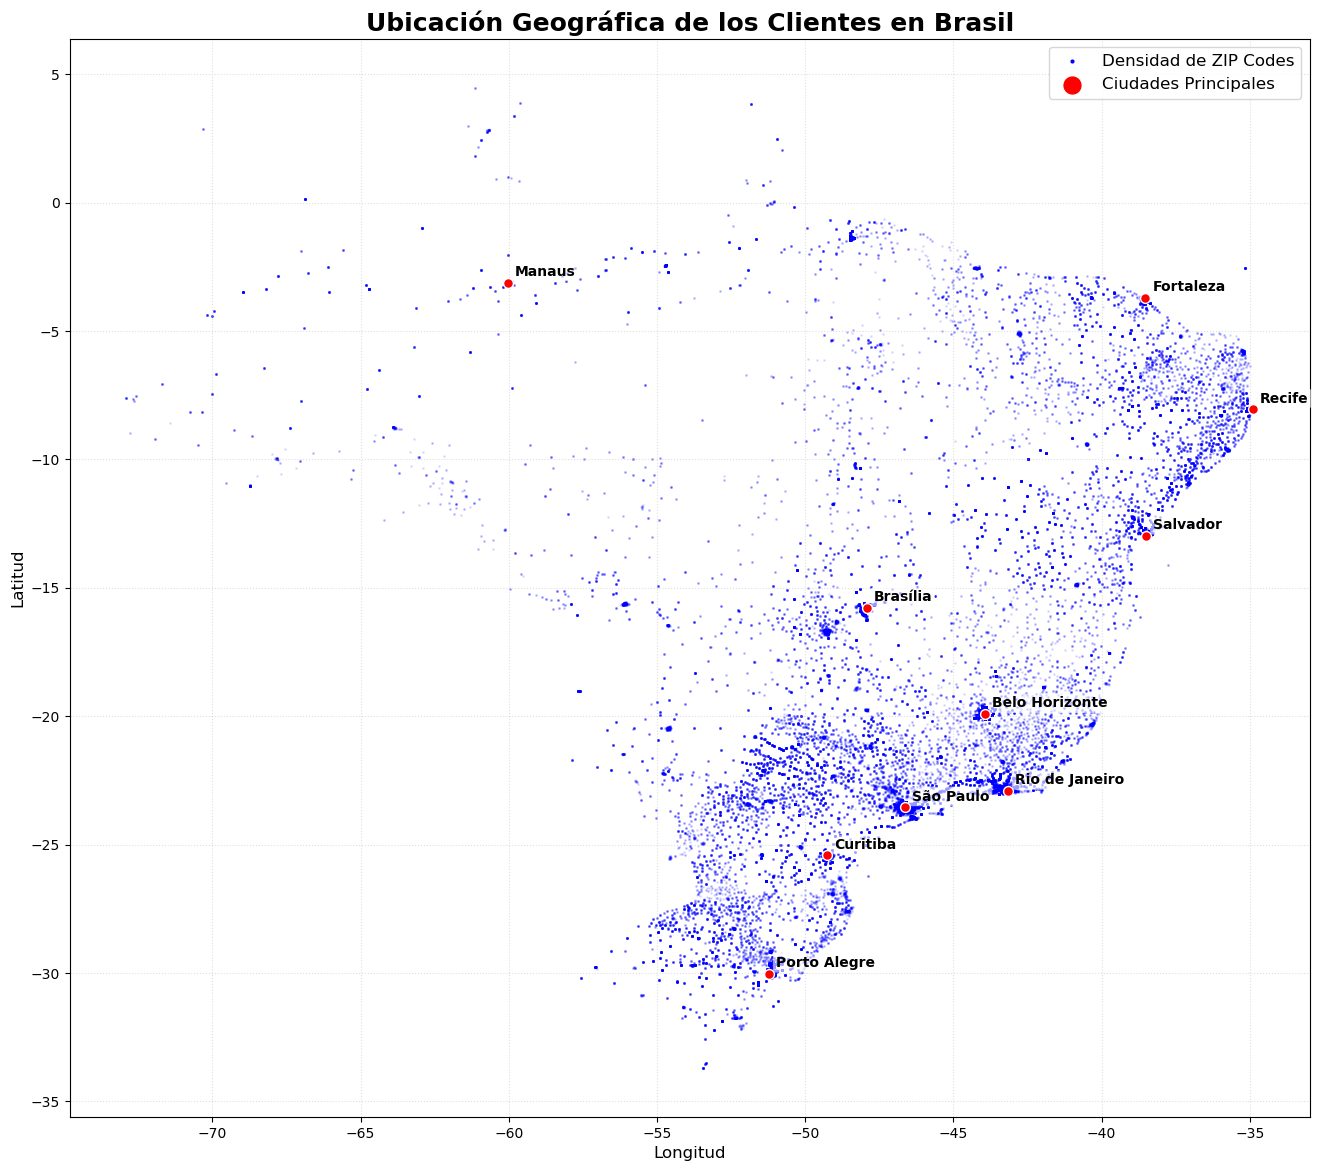

In [25]:
import matplotlib.pyplot as plt

# 1. Definir las coordenadas de las ciudades (mantenemos tu dict)
cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

plt.figure(figsize=(16, 14))

# --- CAPA 1: Densidad de Pedidos/Clientes (Azul) ---
# Usamos ogd_clean para evitar que los outliers arruinen la escala
ogd_plt = ogd[(ogd['geolocation_lat'] <= 5) & (ogd['geolocation_lat'] >= -35)]
ogd_plt = ogd_plt[(ogd_plt['geolocation_lng'] <= -35) & (ogd_plt['geolocation_lng'] >= -75)]

plt.scatter(ogd_plt['geolocation_lng'], ogd_plt['geolocation_lat'], 
            alpha=0.1, s=1, c='blue', label='Densidad de ZIP Codes')


# --- CAPA 2: Ciudades Principales (Rojo) ---
first_city = True
for city, coords in cities.items():
    lat, lng = coords
    lbl = 'Ciudades Principales' if first_city else ""
    
    # Punto rojo con borde blanco (tu estilo)
    plt.scatter(lng, lat, c='red', s=50, edgecolors='white', zorder=5, label=lbl)
    
    # Anotación con desplazamiento y caja (tu estilo)
    plt.annotate(city, 
                 xy=(lng, lat), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=10,
                 fontweight='bold',
                 color='black',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
                 zorder=6)
    first_city = False

# --- ESTÉTICA Y LEYENDA CONSISTENTE ---
plt.title('Ubicación Geográfica de los Clientes en Brasil', fontsize=18, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

# Creamos la leyenda
leg = plt.legend(markerscale=2, fontsize=12, loc='upper right', frameon=True)

# TRUCO DE CONSISTENCIA: Forzamos que los iconos de la leyenda sean opacos
# para que el azul y el naranja se identifiquen perfectamente
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.show()

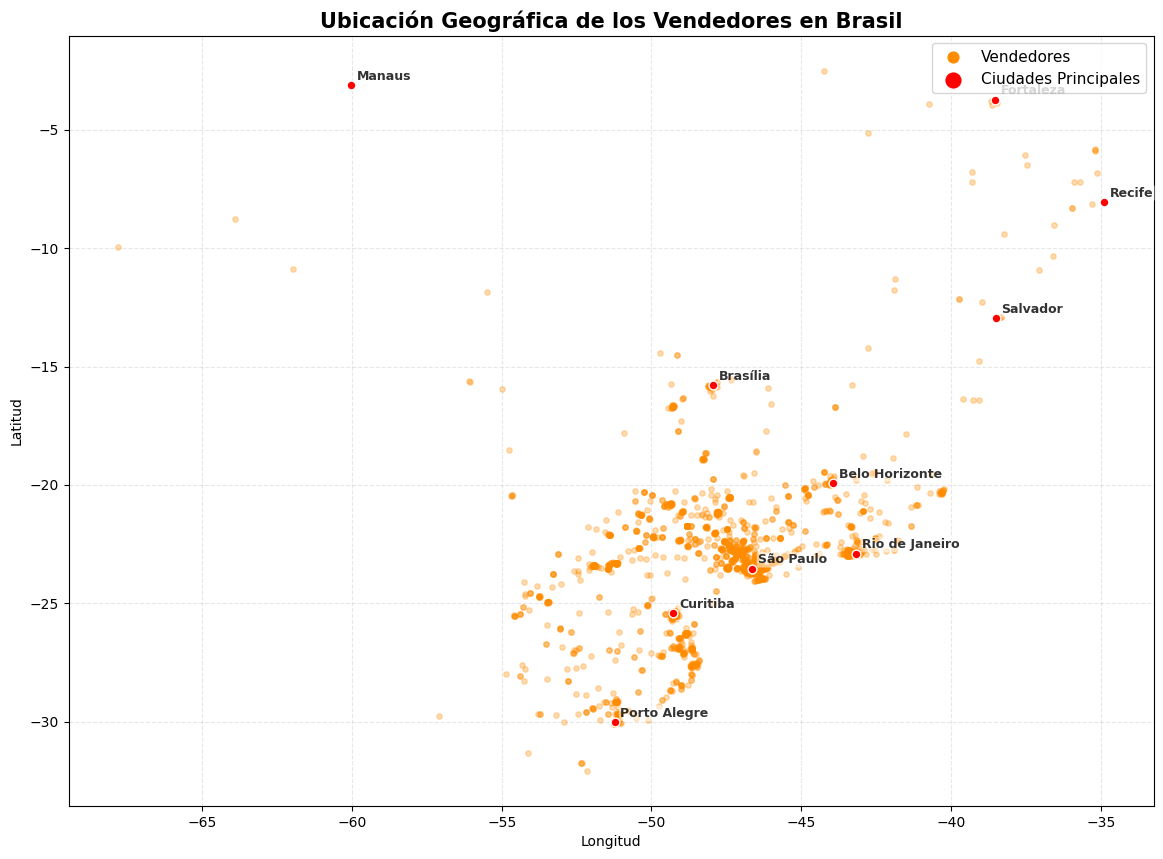

Total de vendedores mapeados: 3088


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Cargar y preparar los datos de vendedores (osd)
sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
osd = sellers.drop(['seller_city', 'seller_state'], axis=1)
osd = pd.merge(osd, ogd, left_on='seller_zip_code_prefix', right_index=True)
osd = osd.drop(['seller_zip_code_prefix'], axis=1)

# 2. Configuración del Plot
plt.figure(figsize=(14, 10))

# CAPA 1: Vendedores (Naranja)
plt.scatter(osd['geolocation_lng'], osd['geolocation_lat'], 
            alpha=0.3, 
            s=15, 
            c='darkorange', 
            label='Vendedores')

# CAPA 2: Ciudades Principales (Rojo)
cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

# Dibujamos las ciudades y gestionamos la leyenda para que no se repita
first_city = True
for city, coords in cities.items():
    lat, lng = coords
    lbl = 'Ciudades Principales' if first_city else ""
    # Punto rojo de la ciudad
    plt.scatter(lng, lat, c='red', s=40, edgecolors='white', zorder=5, label=lbl)
    # Etiqueta de texto
    plt.annotate(city, 
                 xy=(lng, lat), 
                 xytext=(4, 4), 
                 textcoords='offset points', 
                 fontsize=9, 
                 fontweight='bold', 
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))
    first_city = False

# 3. Estética y Leyenda Consistente
plt.title('Ubicación Geográfica de los Vendedores en Brasil', fontsize=15, fontweight='bold')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.3)

# Generar la leyenda
leg = plt.legend(markerscale=2, fontsize=11, loc='upper right', frameon=True)

# Forzar opacidad en los iconos de la leyenda
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.show()

# Resumen
print(f"Total de vendedores mapeados: {len(osd)}")

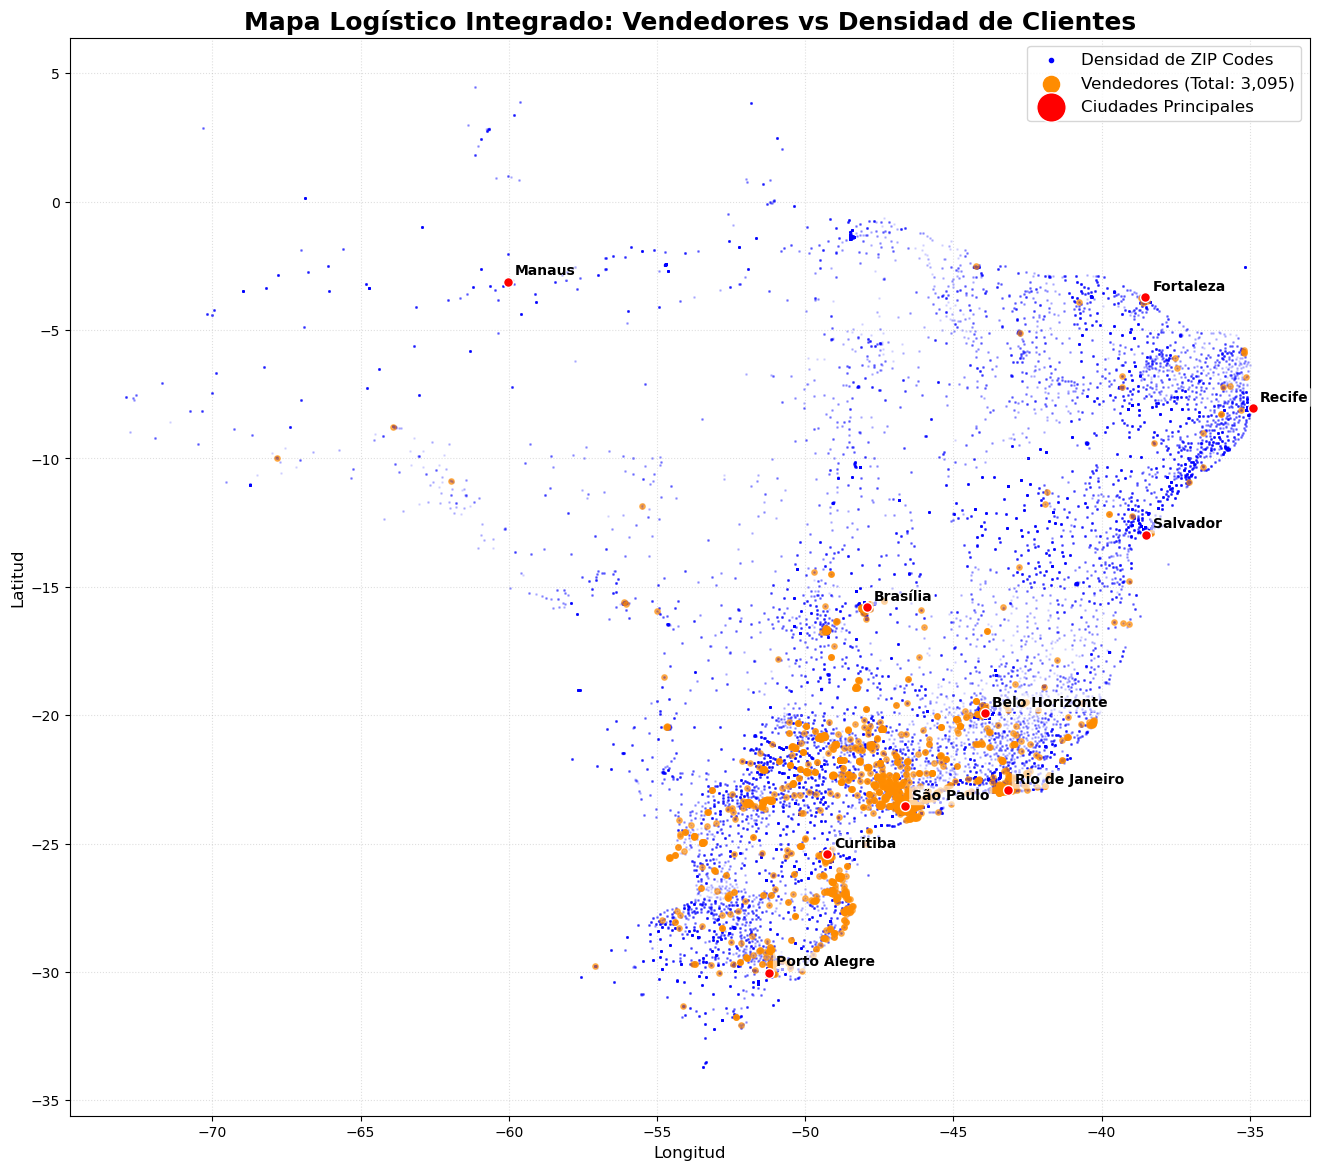

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Preparación de datos (Filtro de outliers para escala correcta)
ogd_plt = ogd[(ogd['geolocation_lat'] <= 5) & (ogd['geolocation_lat'] >= -35)]
ogd_plt = ogd_plt[(ogd_plt['geolocation_lng'] <= -35) & (ogd_plt['geolocation_lng'] >= -75)]

plt.figure(figsize=(16, 14))

# --- CAPA 1: Puntos Azules (Clientes) ---
# Ajustamos alpha=0.1 y s=1 para igualar la intensidad del primer plot
plt.scatter(ogd_plt['geolocation_lng'], ogd_plt['geolocation_lat'], 
            c='blue', 
            alpha=0.1,       # <--- Igual que en el plot de solo clientes
            s=1,             # <--- Igual que en el plot de solo clientes
            label='Densidad de ZIP Codes',
            zorder=1)

# --- CAPA 2: Puntos Naranjas (Vendedores) ---
plt.scatter(osd['geolocation_lng'], osd['geolocation_lat'], 
            c='darkorange', 
            alpha=0.6,       # Subimos un poco para que no se pierdan sobre el azul fuerte
            s=15, 
            label='Vendedores (Total: 3,095)', 
            zorder=2)        # zorder=2 asegura que el naranja esté "encima" del azul

# --- CAPA 3: Ciudades (Puntos Rojos) ---
cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

first_city = True
for city, coords in cities.items():
    lat, lng = coords
    lbl = 'Ciudades Principales' if first_city else ""
    # Punto rojo con borde blanco
    plt.scatter(lng, lat, c='red', s=50, edgecolors='white', zorder=5, label=lbl)
    # Anotación
    plt.annotate(city, 
                 xy=(lng, lat), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=10,
                 fontweight='bold',
                 color='black',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
                 zorder=6)
    first_city = False

# --- ESTÉTICA Y LEYENDA ---
plt.title('Mapa Logístico Integrado: Vendedores vs Densidad de Clientes', fontsize=18, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

leg = plt.legend(markerscale=3, fontsize=12, loc='upper right', frameon=True)

# Forzamos opacidad total en la leyenda para que los colores sean claros
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.show()